# IPL Ball-by-Ball Analysis (2008-2024)

Exploratory analysis of 1,095 IPL matches and 260,000+ ball-by-ball records to uncover patterns in team strategy, player performance, and venue behavior.

**Dataset:** [IPL Complete Dataset 2008-2024](https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020) (Kaggle)

**Questions explored:**
1. Does batting first or chasing give a competitive edge?
2. Which bowlers are most economical in death overs (16-20)?
3. Which top batsmen are most consistent vs "boom or bust"?
4. Has toss advantage changed over the years?
5. Which venues are most batting-friendly vs bowling-friendly?

In [1]:
import pandas as pd

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(matches.columns.tolist())
print(deliveries.shape)
print(deliveries.columns.tolist())

(1095, 20)
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
(260920, 17)
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [2]:
# Matches where team batting first won vs team chasing won
matches_clean = matches.dropna(subset=['winner'])

bat_first_wins = matches_clean[matches_clean['toss_decision'] == 'bat']
chase_wins = matches_clean[matches_clean['toss_decision'] == 'field']

total_decided = len(matches_clean)
print(f"Total decided matches: {total_decided}")

# Simpler approach: compare result column
result_counts = matches_clean['result'].value_counts()
print(result_counts)

Total decided matches: 1090
result
wickets    578
runs       498
tie         14
Name: count, dtype: int64


In [3]:
matches_clean = matches.dropna(subset=['winner', 'toss_decision'])

# Determine which team batted first based on toss + decision
def batted_first(row):
    if row['toss_decision'] == 'bat':
        return row['toss_winner']
    else:
        return row['team1'] if row['toss_winner'] == row['team2'] else row['team2']

matches_clean['team_batting_first'] = matches_clean.apply(batted_first, axis=1)
matches_clean['bat_first_won'] = matches_clean['team_batting_first'] == matches_clean['winner']

win_pct = matches_clean['bat_first_won'].value_counts(normalize=True) * 100
print(win_pct)

bat_first_won
False    54.12844
True     45.87156
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_35788\1965518563.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean['team_batting_first'] = matches_clean.apply(batted_first, axis=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_35788\1965518563.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean['bat_first_won'] = matches_clean['team_batting_first'] == matches_clean['winner']


**Insight:** Chasing teams won 54.1% of matches vs 45.9% for teams batting first — suggesting a real, if modest, advantage to chasing, likely due to knowing the target and pacing accordingly.

In [4]:
death_overs = deliveries[deliveries['over'] >= 15]  # overs are 0-indexed, so 15 = 16th over

bowler_economy = death_overs.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count')
).reset_index()

bowler_economy['overs_bowled'] = bowler_economy['balls_bowled'] / 6
bowler_economy['economy_rate'] = bowler_economy['runs_conceded'] / bowler_economy['overs_bowled']

# Filter for bowlers with meaningful sample size (at least 100 balls in death overs)
bowler_economy_filtered = bowler_economy[bowler_economy['balls_bowled'] >= 100]
top_death_bowlers = bowler_economy_filtered.sort_values('economy_rate').head(10)
print(top_death_bowlers)

            bowler  runs_conceded  balls_bowled  overs_bowled  economy_rate
395  Sohail Tanvir            122           107     17.833333      6.841121
100   DE Bollinger            297           242     40.333333      7.363636
373      SP Narine           1287          1044    174.000000      7.396552
5         A Kumble            217           174     29.000000      7.482759
228   M Theekshana            137           109     18.166667      7.541284
146        J Botha            138           108     18.000000      7.666667
186      KH Pandya            237           184     30.666667      7.728261
365     SL Malinga           1526          1174    195.666667      7.798978
313      RD Chahar            223           170     28.333333      7.870588
297       R Ashwin            816           620    103.333333      7.896774


**Insight:** Sohail Tanvir had the best raw economy rate (6.84) in death overs, though SP Narine's performance across a much larger sample (174 overs) makes his reliability more statistically robust.

In [5]:
# Runs per match per batter
batsman_runs = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index()

batsman_stats = batsman_runs.groupby('batter')['batsman_runs'].agg(['mean', 'std', 'count']).reset_index()
batsman_stats.columns = ['batter', 'avg_runs', 'std_dev', 'innings_played']

# Filter for batters with significant innings (at least 30 innings)
consistent_batsmen = batsman_stats[batsman_stats['innings_played'] >= 30]
consistent_batsmen = consistent_batsmen.sort_values('avg_runs', ascending=False).head(15)
print(consistent_batsmen)

           batter   avg_runs    std_dev  innings_played
289      KL Rahul  38.434426  29.442755             122
473    RD Gaikwad  36.615385  30.724935              65
542      SE Marsh  36.072464  29.014864              69
147     DA Warner  35.690217  28.974206             184
124      CH Gayle  35.439716  33.138965             141
365     ML Hayden  34.593750  26.457342              32
352    MEK Hussey  34.086207  29.156736              58
242    JC Buttler  33.801887  31.555973             106
188  F du Plessis  33.123188  25.326900             138
631       V Kohli  32.844262  27.473300             244
592  Shubman Gill  32.484848  28.896495              99
256   JM Bairstow  31.780000  28.062823              50
122       CA Lynn  31.642857  25.324067              42
208     H Klaasen  31.031250  24.923734              32
662   YBK Jaiswal  30.903846  28.407580              52


In [6]:
# Consistency ratio: lower std_dev relative to avg_runs = more consistent
consistent_batsmen['consistency_ratio'] = consistent_batsmen['std_dev'] / consistent_batsmen['avg_runs']
consistent_batsmen_sorted = consistent_batsmen.sort_values('consistency_ratio')
print(consistent_batsmen_sorted[['batter', 'avg_runs', 'std_dev', 'consistency_ratio']])

           batter   avg_runs    std_dev  consistency_ratio
188  F du Plessis  33.123188  25.326900           0.764627
365     ML Hayden  34.593750  26.457342           0.764801
289      KL Rahul  38.434426  29.442755           0.766052
122       CA Lynn  31.642857  25.324067           0.800309
208     H Klaasen  31.031250  24.923734           0.803182
542      SE Marsh  36.072464  29.014864           0.804349
147     DA Warner  35.690217  28.974206           0.811825
631       V Kohli  32.844262  27.473300           0.836472
473    RD Gaikwad  36.615385  30.724935           0.839126
352    MEK Hussey  34.086207  29.156736           0.855382
256   JM Bairstow  31.780000  28.062823           0.883034
592  Shubman Gill  32.484848  28.896495           0.889538
662   YBK Jaiswal  30.903846  28.407580           0.919225
242    JC Buttler  33.801887  31.555973           0.933557
124      CH Gayle  35.439716  33.138965           0.935080


**Insight:** Faf du Plessis and Matthew Hayden were the most statistically consistent top-order batsmen, while Chris Gayle showed the highest variability — matching his real-world reputation as an explosive but unpredictable player.

In [7]:
matches_clean = matches.dropna(subset=['winner', 'toss_winner']).copy()
matches_clean['toss_winner_won_match'] = matches_clean['toss_winner'] == matches_clean['winner']

toss_impact_by_season = matches_clean.groupby('season')['toss_winner_won_match'].mean() * 100
print(toss_impact_by_season)

season
2007/08    48.275862
2009       57.894737
2009/10    51.666667
2011       52.777778
2012       44.594595
2013       47.368421
2014       50.000000
2015       49.122807
2016       56.666667
2017       57.627119
2018       53.333333
2019       61.016949
2020/21    41.666667
2021       58.333333
2022       48.648649
2023       46.575342
2024       43.661972
Name: toss_winner_won_match, dtype: float64


**Insight:** Toss advantage varies significantly year to year (42-61%) with no clear trend, suggesting the common belief that toss/dew heavily influences outcomes is overstated — team quality likely matters more.

In [8]:
# Total runs per match per venue
match_totals = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
match_totals = match_totals.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')

venue_avg_runs = match_totals.groupby('venue')['total_runs'].mean().sort_values(ascending=False)
print(venue_avg_runs.head(10))  # highest scoring venues
print(venue_avg_runs.tail(10))  # lowest scoring (bowling friendly) venues

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Wankhede Stadium, Mumbai                                              346.377778
Name: total_runs, dtype: float64
venue
Shaheed Veer Narayan Singh International Stadium       290.166667
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    288.153846
New Wanderers

**Insight:** M Chinnaswamy Stadium confirms its reputation as one of the most batting-friendly venues in the IPL. Venues with very few matches show unstable averages due to small sample size and should be interpreted cautiously.

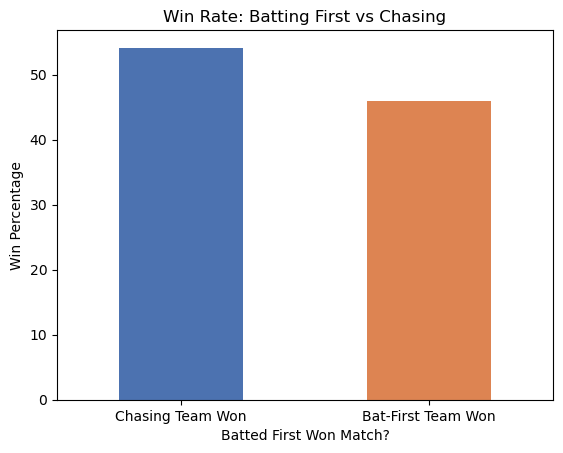

In [9]:
import matplotlib.pyplot as plt

win_pct.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Win Rate: Batting First vs Chasing')
plt.xlabel('Batted First Won Match?')
plt.ylabel('Win Percentage')
plt.xticks([0, 1], ['Chasing Team Won', 'Bat-First Team Won'], rotation=0)
plt.show()

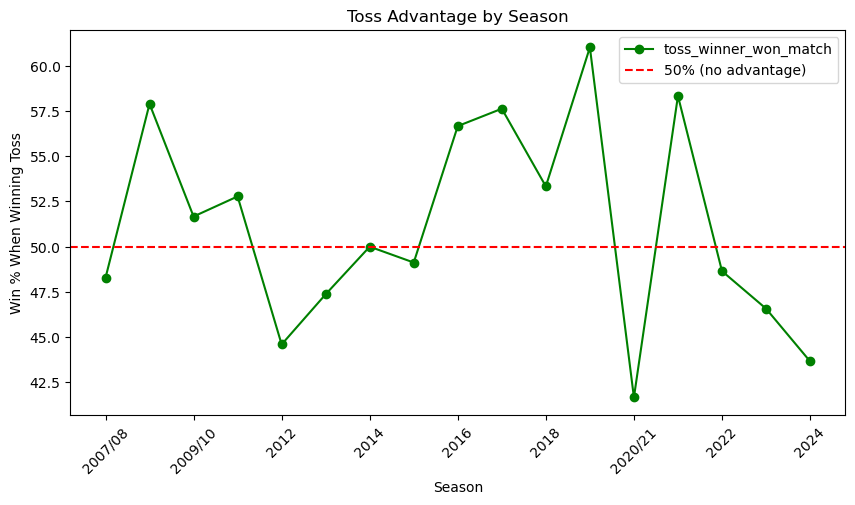

In [10]:
toss_impact_by_season.plot(kind='line', marker='o', figsize=(10,5), color='green')
plt.title('Toss Advantage by Season')
plt.xlabel('Season')
plt.ylabel('Win % When Winning Toss')
plt.axhline(y=50, color='red', linestyle='--', label='50% (no advantage)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

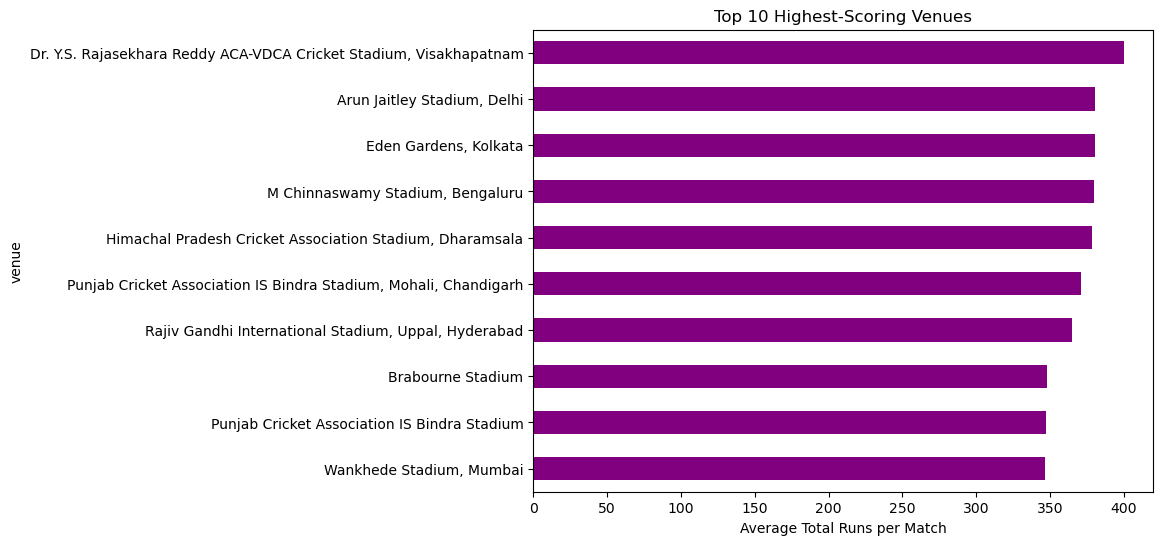

In [11]:
venue_avg_runs.head(10).plot(kind='barh', color='purple', figsize=(8,6))
plt.title('Top 10 Highest-Scoring Venues')
plt.xlabel('Average Total Runs per Match')
plt.gca().invert_yaxis()
plt.show()